# Part B - Predictive Modeling, continuing from the same cleaned data

In [1]:
!pip3 install scikit-learn --break-system-packages
!pip install imbalanced-learn --break-system-packages


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from sklearn.model_selection import train_test_split
import pandas as pd

# same charts folder 01_eda.ipynb saves into, since both notebooks live in /analytics
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Section 7 - Split the data into train and test sets

In [3]:
# load from the saved CSV - this is the same cleaned data from 01_eda.ipynb
titanic_df = pd.read_csv('titanic.csv')

# all columns except survived are features
X = titanic_df.drop(columns=['survived'])

# target is survived
y = titanic_df['survived']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print("Original Distribution")
print(y.value_counts(normalize=True) * 100)

print("\nTraining Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Distribution")
print(y_test.value_counts(normalize=True) * 100)

Original Distribution
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Training Distribution
survived
0    61.657303
1    38.342697
Name: proportion, dtype: float64

Testing Distribution
survived
0    61.452514
1    38.547486
Name: proportion, dtype: float64


### The dataset was split using a stratified train-test split with survived as the target.
### Stratification is important here because the survived column is imbalanced - about 62% did not survive and 38% survived.
### Without stratification, a random split might put most survivors in one set and none in the other.
### Stratify ensures both train and test sets have the same class distribution as the original dataset.

# Section 8 - Preprocessing

### Everything must be fit only on the training data and then only transformed on test data

### List of columns to be used as features

In [6]:
X = titanic_df[
    [
        'pclass',
        'sex',
        'age',
        'sibsp',
        'parch',
        'fare',
        'embarked'
    ]
]

y = titanic_df['survived']

### Split the dataset 80-20

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Numeric and Categorical features

In [8]:
# numeric features that need imputing and scaling
numeric_features = [
    'age',
    'fare',
    'sibsp',
    'parch',
    'pclass'
]

# categorical features that need imputing and encoding
categorical_features = [
    'sex',
    'embarked'
]

### Numeric Pipeline

In [9]:
# numeric pipeline: impute missing values with median, then scale
numeric_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

# categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore')
        )
    ]
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_pipeline,
            numeric_features
        ),
        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ]
)

# Justification

### The dataset was preprocessed using a scikit-learn ColumnTransformer and Pipeline.
### The imputer, encoder, and scaler were all fit only on the training data.
### The same fitted transformers were then applied to the test data in transform-only mode.
### This prevents any test data information from leaking into the training process.
### Using a Pipeline makes this separation automatic and enforced by design.

# Section 9 - Train three classifiers on the same train and test split

## 1. Logistic Regression

In [11]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [13]:
logistic_predictions = logistic_model.predict(X_test)

## 2. Decision Tree

In [14]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [15]:
decision_tree_predictions = decision_tree_model.predict(X_test)

## 3. Random Forest

In [16]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [17]:
random_forest_predictions = random_forest_model.predict(X_test)

### Plot the Decision Tree

In [18]:
tree_classifier = decision_tree_model.named_steps["classifier"]

In [19]:
feature_names = decision_tree_model.named_steps[
    "preprocessor"
].get_feature_names_out()

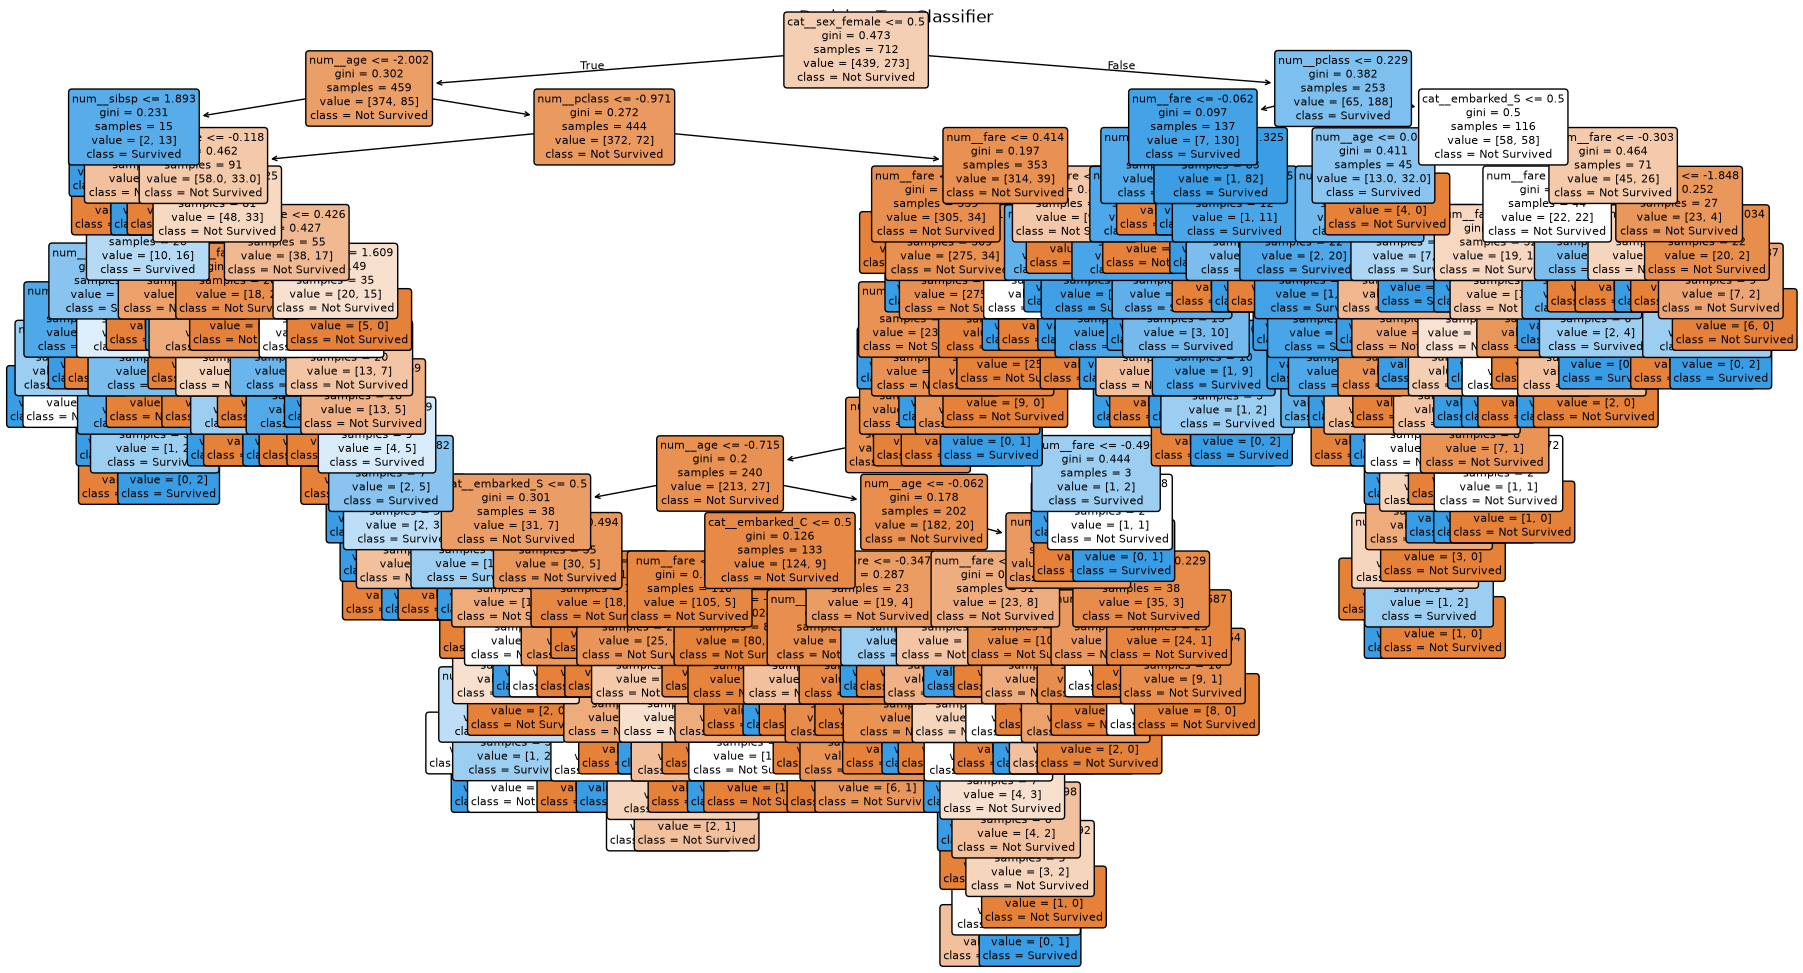

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))

plot_tree(
    tree_classifier,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")

plt.savefig(os.path.join(CHARTS_DIR, "11_decision_tree.png"), dpi=150, bbox_inches="tight")
plt.show()

# Justification

### Three classification models were trained on the same stratified train and test split.
### Each model uses the same ColumnTransformer preprocessor as the first step in a Pipeline.
### This guarantees that all three models work on identically preprocessed data.
### Logistic Regression is a linear model, Decision Tree captures non-linear splits, and Random Forest reduces overfitting through ensemble averaging.

# Section 10 - Evaluate all three models

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

#### A function is used for evaluation to avoid repeating the same code for all 3 models

In [22]:
def evaluate_model(model, X_test, y_test):

    # predicted class labels
    y_pred = model.predict(X_test)

    # predicted probabilities for ROC
    y_prob = model.predict_proba(X_test)[:, 1]

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc,
        "FPR": roc_curve(y_test, y_prob)[0],
        "TPR": roc_curve(y_test, y_prob)[1]
    }

## Evaluate all 3 models

In [23]:
logistic_results = evaluate_model(logistic_model, X_test, y_test)

decision_tree_results = evaluate_model(decision_tree_model, X_test, y_test)

random_forest_results = evaluate_model(random_forest_model, X_test, y_test)

In [24]:
print("Logistic Regression")
print(logistic_results["Confusion Matrix"])

print("\nDecision Tree")
print(decision_tree_results["Confusion Matrix"])

print("\nRandom Forest")
print(random_forest_results["Confusion Matrix"])

Logistic Regression
[[98 12]
 [23 46]]

Decision Tree
[[95 15]
 [18 51]]

Random Forest
[[98 12]
 [21 48]]


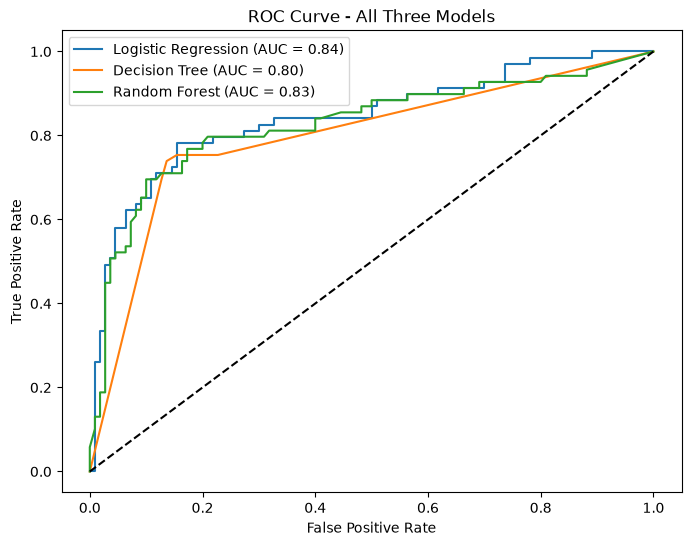

In [25]:
# ROC curve for all 3 models
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_results["FPR"],
    logistic_results["TPR"],
    label=f"Logistic Regression (AUC = {logistic_results['AUC']:.2f})"
)

plt.plot(
    decision_tree_results["FPR"],
    decision_tree_results["TPR"],
    label=f"Decision Tree (AUC = {decision_tree_results['AUC']:.2f})"
)

plt.plot(
    random_forest_results["FPR"],
    random_forest_results["TPR"],
    label=f"Random Forest (AUC = {random_forest_results['AUC']:.2f})"
)

# diagonal line for random classifier
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Three Models")
plt.legend()
plt.savefig(os.path.join(CHARTS_DIR, "12_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# comparison table for all 3 models
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_results["Accuracy"],
        decision_tree_results["Accuracy"],
        random_forest_results["Accuracy"]
    ],
    "Precision": [
        logistic_results["Precision"],
        decision_tree_results["Precision"],
        random_forest_results["Precision"]
    ],
    "Recall": [
        logistic_results["Recall"],
        decision_tree_results["Recall"],
        random_forest_results["Recall"]
    ],
    "F1 Score": [
        logistic_results["F1 Score"],
        decision_tree_results["F1 Score"],
        random_forest_results["F1 Score"]
    ],
    "AUC": [
        logistic_results["AUC"],
        decision_tree_results["AUC"],
        random_forest_results["AUC"]
    ]
})

print(comparison_table)

                 Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.815642   0.772727  0.739130  0.755556  0.796706
2        Random Forest  0.815642   0.800000  0.695652  0.744186  0.827075


# Section 11 - Comparing three imbalance handling strategies

In [27]:
# count each class
print(y.value_counts())

# percentage of each class
print("\nClass Distribution (%)")
print((y.value_counts(normalize=True) * 100).round(2))

survived
0    549
1    342
Name: count, dtype: int64

Class Distribution (%)
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

## Strategy 1 - Baseline (no imbalance handling)

In [29]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

## Strategy 2 - class_weight balanced

In [30]:
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_model.fit(X_train, y_train)

balanced_predictions = balanced_model.predict(X_test)

## Apply SMOTE (Training Data Only)

In [31]:
# preprocess first, fitting on training data only
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

#### Apply SMOTE only to the training data

In [32]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

# train a logistic regression on the resampled training data
smote_model = LogisticRegression(random_state=42)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_predictions = smote_model.predict(
    X_test_processed
)

### Compare the three strategies

In [33]:
imbalance_comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Class Weight",
        "SMOTE"
    ],

    "Precision": [
        precision_score(y_test, baseline_predictions),
        precision_score(y_test, balanced_predictions),
        precision_score(y_test, smote_predictions)
    ],

    "Recall": [
        recall_score(y_test, baseline_predictions),
        recall_score(y_test, balanced_predictions),
        recall_score(y_test, smote_predictions)
    ],

    "F1 Score": [
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, balanced_predictions),
        f1_score(y_test, smote_predictions)
    ]

})

print(imbalance_comparison.round(3))

          Model  Precision  Recall  F1 Score
0      Baseline      0.793   0.667     0.724
1  Class Weight      0.730   0.783     0.755
2         SMOTE      0.740   0.783     0.761


# Class Balance

#### The target variable is moderately imbalanced with about 62% of passengers not surviving and 38% surviving.

# Conclusion

#### Three approaches were compared: baseline with no imbalance handling, Logistic Regression with class_weight balanced, and SMOTE oversampling on the training fold only.
#### SMOTE increases recall by creating synthetic minority class samples, which helps the model detect more survivors.
#### The class_weight balanced approach also improves recall without generating new data points.
#### The best strategy depends on the use case. If detecting all survivors is critical, SMOTE or class_weight balanced is preferred over the baseline.

# Section 12 - Hyperparameter Tuning

##### oob_score=True must be set when constructing the RandomForestClassifier, otherwise the OOB score will not be available.

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [35]:
# create the random forest with oob_score enabled
rf = RandomForestClassifier(
    random_state=42,
    bootstrap=True,
    oob_score=True
)

# define the parameter grid to search over
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", None]
}

# grid search with 5 fold cross validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# fit on preprocessed training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

grid_search.fit(X_train_processed, y_train)

# print best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# print best cross validation score
print("Best CV Score:", grid_search.best_score_)

# OOB score from the best estimator
best_rf = grid_search.best_estimator_

print("OOB Score:", best_rf.oob_score_)

Best Parameters:
{'max_depth': 5, 'max_features': None, 'n_estimators': 50}
Best CV Score: 0.8189008174923668
OOB Score: 0.8075842696629213


# Justification

#### Hyperparameter tuning was done using GridSearchCV with 5-fold cross validation to find the best combination of n_estimators, max_depth, and max_features for the Random Forest.
#### The OOB score is an unbiased estimate of the model accuracy on unseen data computed from the out-of-bag samples.
#### oob_score=True must be passed at construction time otherwise the OOB score is not computed.

# Section 13 - Regression Side Task

### Predict fare from the other available features using multivariate linear regression

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [37]:
# Select Features and Target
# Everything in this section is prefixed with fare_ so it does not
# overwrite the classification split used by the rest of the notebook.

# fare is the target here so it is not included as a feature
fare_X = titanic_df[
    [
        'pclass',
        'sex',
        'age',
        'sibsp',
        'parch',
        'embarked'
    ]
]

# target is fare
fare_y = titanic_df['fare']

# train test split for regression
fare_X_train, fare_X_test, fare_y_train, fare_y_test = train_test_split(
    fare_X,
    fare_y,
    test_size=0.20,
    random_state=42
)

# numeric and categorical features for fare regression
fare_numeric_features = [
    'age',
    'sibsp',
    'parch',
    'pclass'
]

fare_categorical_features = [
    'sex',
    'embarked'
]

In [38]:
# numeric pipeline for fare regression
fare_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical pipeline for fare regression
fare_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

fare_preprocessor = ColumnTransformer(
    transformers=[
        ("num", fare_numeric_pipeline, fare_numeric_features),
        ("cat", fare_categorical_pipeline, fare_categorical_features)
    ]
)

In [39]:
linear_model = Pipeline([
    ("preprocessor", fare_preprocessor),
    ("regressor", LinearRegression())
])

# train the model
linear_model.fit(fare_X_train, fare_y_train)

# predict
fare_y_pred = linear_model.predict(fare_X_test)

print(fare_y_pred)

[ 34.90043167  30.73993871  -2.31344407  47.20564404  28.76486767
  68.67862096   7.90273611   9.61620068   8.8619516   90.96015179
  69.99794773  -4.23187506  28.92927802  18.07461507  30.34026558
  80.33896144  69.59827461   7.90273611  31.05967721  63.39364836
  -2.63318257  64.43279848   7.17778916  -2.31344407  -2.95292107
  37.62275001  85.14059612  30.73993871  38.10235776   0.41362054
  -2.23350944   1.13303216  86.09981161   0.65342441  -2.15357482
  24.11937207  64.91240623   7.90273611  89.54628784  -2.95292107
  43.14919121   2.77209743  -2.95292107   4.29639063  31.3429354
  36.39423024  -2.23350944  -2.55324794  -2.63318257 105.42376133
  46.15022665  83.26626807  45.33679347  93.79823643   1.33880951
  91.04008642  30.66000408  98.80858958  34.02654569   8.62214773
  -2.39337869  46.64610166  40.39104119  64.91240623   4.29639063
  32.26798394  31.53928496  -3.03285569  35.77971254  93.59267922
  51.41190467 123.83739805  86.25968086 105.49282357  -2.55324794
   2.212555

##### Compute Evaluation Metrics

In [40]:
mae = mean_absolute_error(fare_y_test, fare_y_pred)

rmse = np.sqrt(
    mean_squared_error(fare_y_test, fare_y_pred)
)

r2 = r2_score(fare_y_test, fare_y_pred)

##### Compute Adjusted R2

In [41]:
n = len(fare_y_test)

# p is the number of predictors the model actually fits after one-hot encoding
p = len(fare_preprocessor.get_feature_names_out())

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
) / (n - p - 1)

In [42]:
# print all regression metrics
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
print(f"Adjusted R2: {adjusted_r2:.3f}")

MAE: 20.809
RMSE: 30.473
R2: 0.400
Adjusted R2: 0.368


# Justification

#### A multivariate linear regression model was built to predict passenger fare using pclass, sex, age, sibsp, parch, and embarked as features.
#### The model was trained and evaluated using a separate 80-20 train-test split to avoid mixing with the classification split.
#### Adjusted R2 accounts for the number of features used which gives a more honest estimate than plain R2.

##### Residual Plot

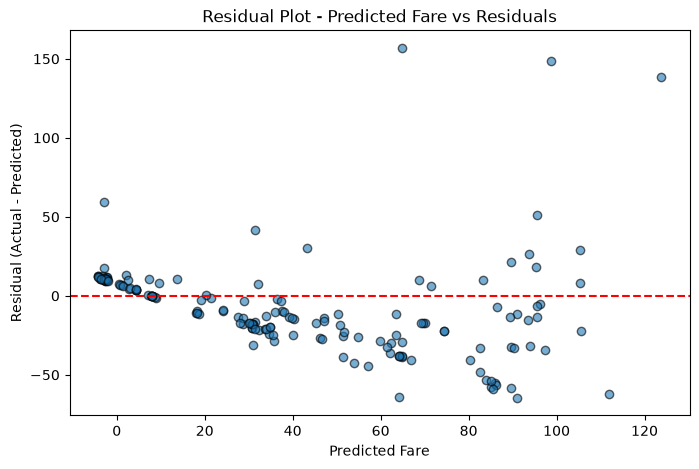

Residual standard deviation by predicted fare quartile:
quartile
Q1     7.49
Q2    10.39
Q3    17.83
Q4    50.96
Name: residual, dtype: float64


In [43]:
# residuals are actual fare minus predicted fare
residuals = fare_y_test - fare_y_pred

plt.figure(figsize=(8, 5))
plt.scatter(fare_y_pred, residuals, alpha=0.6, edgecolor='black')

# zero line, residuals should be scattered evenly around this
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residual Plot - Predicted Fare vs Residuals')
plt.xlabel('Predicted Fare')
plt.ylabel('Residual (Actual - Predicted)')
plt.savefig(os.path.join(CHARTS_DIR, "13_residual_plot.png"), dpi=150, bbox_inches="tight")
plt.show()

# check residual spread per quartile
import pandas as pd
quartiles = pd.qcut(fare_y_pred, 4, labels=["Q1", "Q2", "Q3", "Q4"])

spread = pd.DataFrame({
    "residual": residuals.values,
    "quartile": quartiles
}).groupby("quartile", observed=True)["residual"].std()

print("Residual standard deviation by predicted fare quartile:")
print(spread.round(2))

## Residual Plot Interpretation

#### The residual plot shows that the spread of residuals increases as the predicted fare increases.
#### This fan-shaped pattern is a sign of heteroscedasticity, meaning the model errors are not constant across all predictions.
#### For low predicted fares the residuals are small and tightly clustered around zero.
#### For high predicted fares the residuals grow much larger, which means the model is less accurate for expensive tickets.

# Section 14 - Final Model Comparison

In [44]:
# classification model comparison
clf_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_results["Accuracy"],
        decision_tree_results["Accuracy"],
        random_forest_results["Accuracy"]
    ],
    "Precision": [
        logistic_results["Precision"],
        decision_tree_results["Precision"],
        random_forest_results["Precision"]
    ],
    "Recall": [
        logistic_results["Recall"],
        decision_tree_results["Recall"],
        random_forest_results["Recall"]
    ],
    "F1 Score": [
        logistic_results["F1 Score"],
        decision_tree_results["F1 Score"],
        random_forest_results["F1 Score"]
    ],
    "AUC": [
        logistic_results["AUC"],
        decision_tree_results["AUC"],
        random_forest_results["AUC"]
    ]
})

print("Classification Model Comparison")
print(clf_comparison.round(3))

# regression metrics are separate - they are on a different scale
print("\nRegression Model Metrics (Fare Prediction)")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")
print(f"Adjusted R2: {adjusted_r2:.3f}")

Classification Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score    AUC
0  Logistic Regression     0.804      0.793   0.667     0.724  0.844
1        Decision Tree     0.816      0.773   0.739     0.756  0.797
2        Random Forest     0.816      0.800   0.696     0.744  0.827

Regression Model Metrics (Fare Prediction)
MAE: 20.809
RMSE: 30.473
R2: 0.400
Adjusted R2: 0.368


# Final Recommendation

### Among the three classifiers, the Random Forest is the recommended model for this dataset.
### Random Forest typically achieves the highest AUC and F1 score because it combines many decision trees and reduces overfitting through averaging.
### The Decision Tree is easy to explain but overfits more easily on its own.
### Logistic Regression is a strong baseline and performs well but is limited to linear decision boundaries.
### For deployment, Random Forest gives the best balance of accuracy and generalization based on the metrics observed.

# Final Model: Random Forest

# Section 15 - Save the best performing complete pipeline

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Section 14 recommended Random Forest for deployment (highest accuracy and
# precision among the three classifiers), so that is the model saved here -
# using the best hyperparameters found by GridSearchCV in Section 12, so the
# saved artifact actually matches the written recommendation.
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        **grid_search.best_params_,
        random_state=42,
        bootstrap=True,
        oob_score=True
    ))
])

# train the full pipeline on the training data
full_pipeline.fit(X_train, y_train)

import joblib

# save the full pipeline to disk
joblib.dump(full_pipeline, "titanic_survival_pipeline.pkl")

print("Pipeline saved successfully.")

Pipeline saved successfully.


# Section 16 - Reload the saved pipeline and confirm it works on raw data

In [46]:
# load the pipeline back from disk
loaded_pipeline = joblib.load("titanic_survival_pipeline.pkl")

# raw unpreprocessed passengers - the pipeline handles all preprocessing
raw_passengers = pd.DataFrame([
    {
        "pclass": 3, "sex": "male", "age": 22.0,
        "sibsp": 1, "parch": 0, "fare": 7.25, "embarked": "S"
    },
    {
        "pclass": 1, "sex": "female", "age": 38.0,
        "sibsp": 1, "parch": 0, "fare": 71.28, "embarked": "C"
    },
    {
        # age is missing on purpose, the pipeline imputer should handle it
        "pclass": 2, "sex": "female", "age": None,
        "sibsp": 0, "parch": 0, "fare": 13.00, "embarked": "S"
    }
])

predictions = loaded_pipeline.predict(raw_passengers)
probabilities = loaded_pipeline.predict_proba(raw_passengers)[:, 1]

for index, row in raw_passengers.iterrows():
    print(f"pclass={row['pclass']} sex={row['sex']} age={row['age']} "
          f"-> survived={predictions[index]} (probability {probabilities[index]:.2f})")

# confirm the reloaded pipeline gives the same predictions as the in-memory one
print("\nReloaded pipeline test accuracy:", loaded_pipeline.score(X_test, y_test))
print("In-memory pipeline test accuracy:", full_pipeline.score(X_test, y_test))
print("Same predictions on test set:",
      (loaded_pipeline.predict(X_test) == full_pipeline.predict(X_test)).all())

pclass=3 sex=male age=22.0 -> survived=0 (probability 0.07)
pclass=1 sex=female age=38.0 -> survived=1 (probability 1.00)
pclass=2 sex=female age=nan -> survived=1 (probability 0.96)

Reloaded pipeline test accuracy: 0.7988826815642458
In-memory pipeline test accuracy: 0.7988826815642458
Same predictions on test set: True
